# Credit Risk Analysis with Python and SQL

## Objective

The objective of this project is to analyze borrower-level credit data and build a baseline statistical model for credit risk classification. The analysis focuses on exploratory data analysis, target imbalance, borrower characteristics and interpretable baseline modeling.

## Dataset

The dataset used is the German Credit dataset from OpenML. It contains 1,000 borrower-level observations, 20 predictor variables and one binary target variable, `class`, indicating whether a borrower is classified as a good or bad credit risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
credit = fetch_openml(name="credit-g", version=1, as_frame=True)
df = credit.frame

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 1. Data Loading and Initial Inspection

The first step is to inspect the structure of the dataset, variable types, missing values and basic descriptive statistics.

In [3]:
df.shape

(1000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [5]:
df.describe(include="all")

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,...,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,...,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,...,car,NaN,none,own,NaN,skilled,NaN,none,yes,good
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,...,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,...,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,...,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,...,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,...,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,...,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,...,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,NaN


In [6]:
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

## Initial Observations

The dataset contains 1,000 borrower-level observations and 21 variables. The target variable is `class`, which has two categories: `good` and `bad`. There are 700 observations classified as `good` and 300 as `bad`, so the dataset is moderately imbalanced.

There are no missing values in the dataset. This simplifies the first stage of the analysis, although categorical encoding will still be required before fitting statistical or machine learning models.

The dataset contains 7 numerical variables and 14 categorical variables. The numerical variables include `duration`, `credit_amount`, `installment_commitment`, `residence_since`, `age`, `existing_credits`, and `num_dependents`. The remaining variables are categorical and describe borrower characteristics such as checking account status, credit history, savings status, employment, housing, job type, and foreign worker status.

The average loan duration is approximately 20.9 months, with values ranging from 4 to 72 months. The average credit amount is approximately 3,271, with a wide range from 250 to 18,424, suggesting substantial variation in loan size. The average borrower age is approximately 35.5 years, with ages ranging from 19 to 75.

Several categorical variables are highly concentrated in one category. For example, most borrowers have no other parties involved, most have no other payment plans, most own their housing, and most are classified as foreign workers. These imbalances should be considered when interpreting model coefficients or feature importance.

Before modeling, the next steps are to inspect the target distribution, visualize key numerical variables, compare default rates across categorical groups, encode categorical features, and build a baseline logistic regression model.

## 2. Target Variable Distribution

Before modeling, it is important to inspect the distribution of the target variable. In credit risk problems, class imbalance is common and affects the interpretation of model performance.

In [7]:
df["class"].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [8]:
df["class"].value_counts(normalize=True)

class
good    0.7
bad     0.3
Name: proportion, dtype: float64

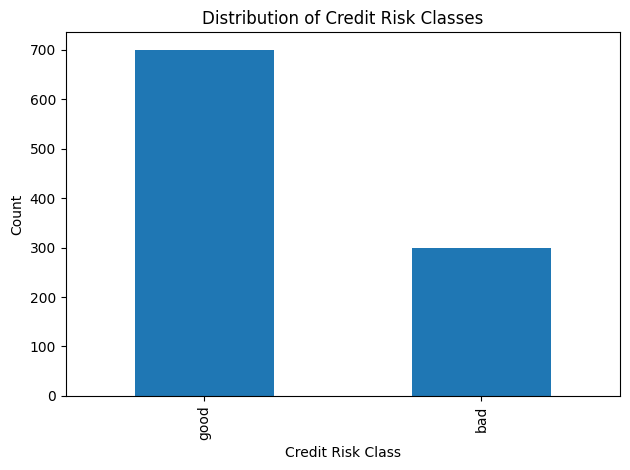

In [9]:
df["class"].value_counts().plot(kind="bar")
plt.title("Distribution of Credit Risk Classes")
plt.xlabel("Credit Risk Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target distribution shows that 70% of borrowers are classified as good credit risks and 30% as bad credit risks. This means that accuracy alone may be misleading as an evaluation metric. For the classification model, precision, recall, F1-score, and the confusion matrix should also be considered.

## 3. Numerical Variable Distributions

The following histograms show the distributions of the numerical predictors. This helps identify skewness, outliers and variables with limited variation.

In [10]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object')

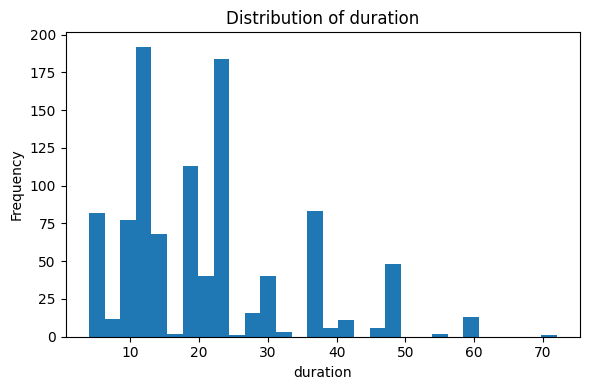

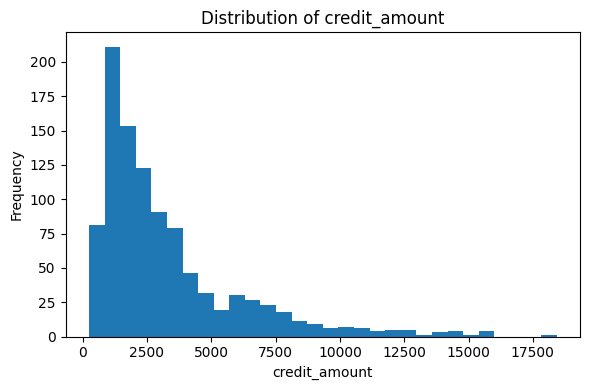

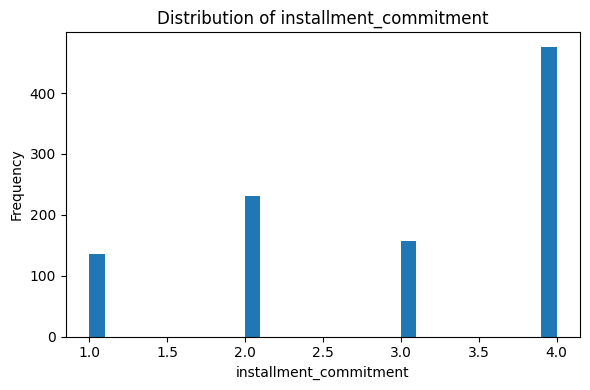

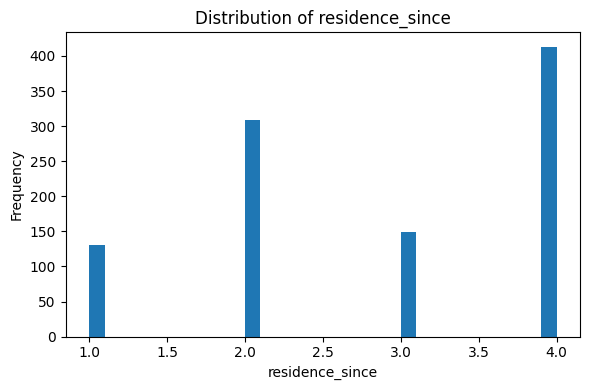

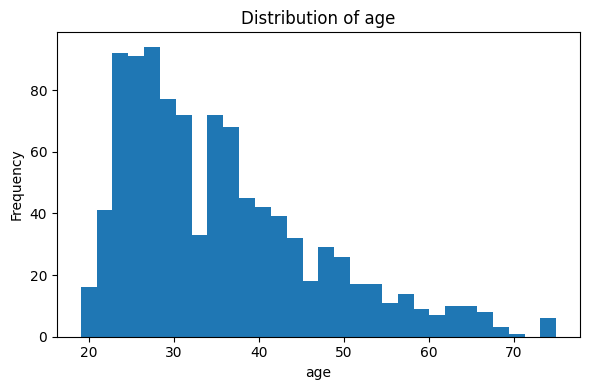

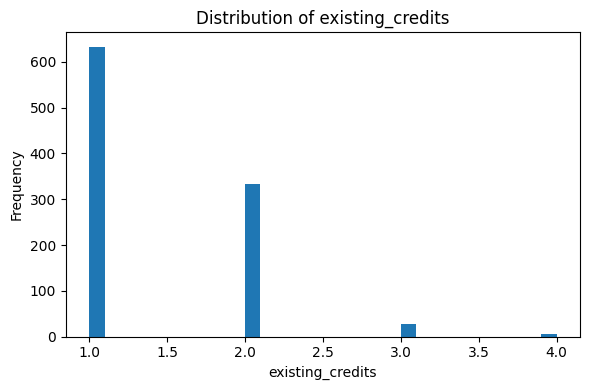

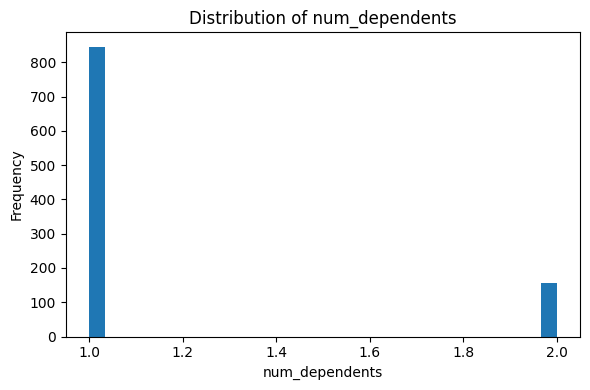

In [11]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

from pathlib import Path

figures_path = Path("../figures")
figures_path.mkdir(parents=True, exist_ok=True)

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].plot(kind="hist", bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(figures_path / f"distribution_{col}.png")
    plt.show()

## 4. Relationship Between Numerical Variables and Credit Risk

The next step is to compare numerical predictors across the two credit risk classes. This helps identify whether variables such as loan duration, credit amount, age, or installment commitment differ between good and bad credit risk borrowers.

In [12]:
df.groupby("class", observed=True)[numeric_cols].mean()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
class,,,,,,,
bad,24.860000,3938.126667,3.096667,2.850000,33.963333,1.366667,1.153333
good,19.207143,2985.457143,2.920000,2.842857,36.224286,1.424286,1.155714


In [13]:
df.groupby("class", observed=True)[numeric_cols].median()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
class,,,,,,,
bad,24.0,2574.5,4.0,3.0,31.0,1.0,1.0
good,18.0,2244.0,3.0,3.0,34.0,1.0,1.0


### Numerical Comparison by Credit Risk Class

Borrowers classified as bad credit risks tend to have longer loan durations than borrowers classified as good credit risks. The average duration is approximately 24.9 months for bad credit risks compared with 19.2 months for good credit risks. The median duration is also higher for bad credit risks, 24 months compared with 18 months.

Bad credit risk borrowers also have higher average credit amounts. The average credit amount is approximately 3,938 for bad credit risks compared with 2,985 for good credit risks. This suggests that both loan size and loan duration may be relevant predictors of credit risk.

The average age of bad credit risk borrowers is slightly lower than that of good credit risk borrowers, approximately 34.0 years compared with 36.2 years. Other numerical variables, such as existing credits and number of dependents, show less visible separation between the two classes.

These comparisons are descriptive and should not be interpreted causally. They provide motivation for including variables such as `duration`, `credit_amount`, and `age` in a baseline classification model.

<Figure size 600x400 with 0 Axes>

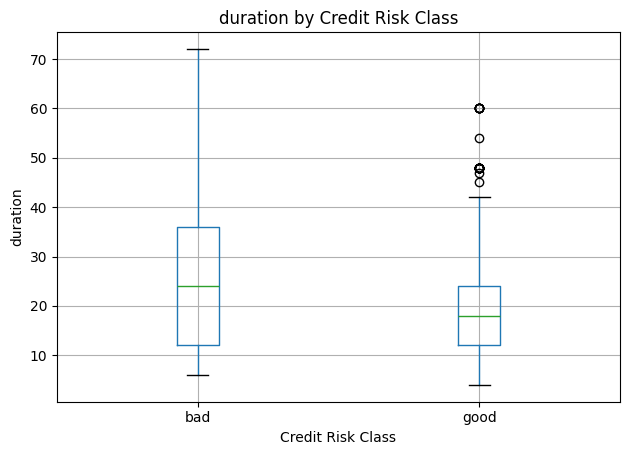

<Figure size 600x400 with 0 Axes>

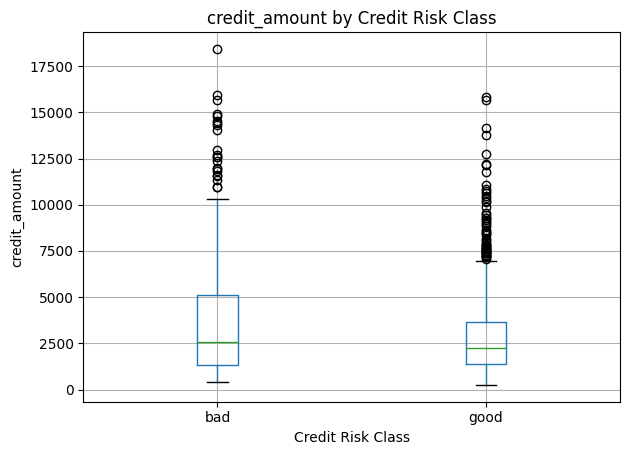

<Figure size 600x400 with 0 Axes>

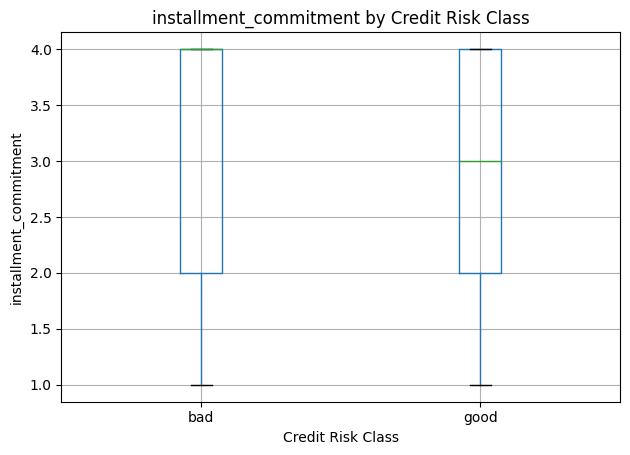

<Figure size 600x400 with 0 Axes>

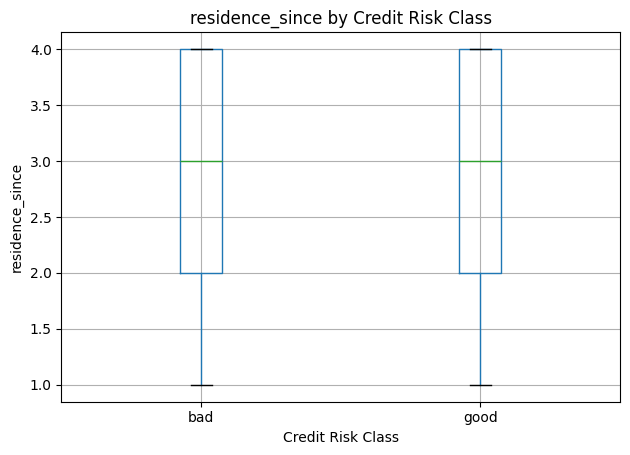

<Figure size 600x400 with 0 Axes>

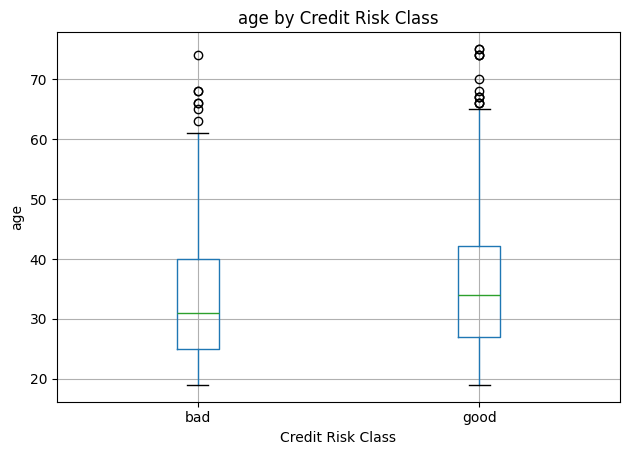

<Figure size 600x400 with 0 Axes>

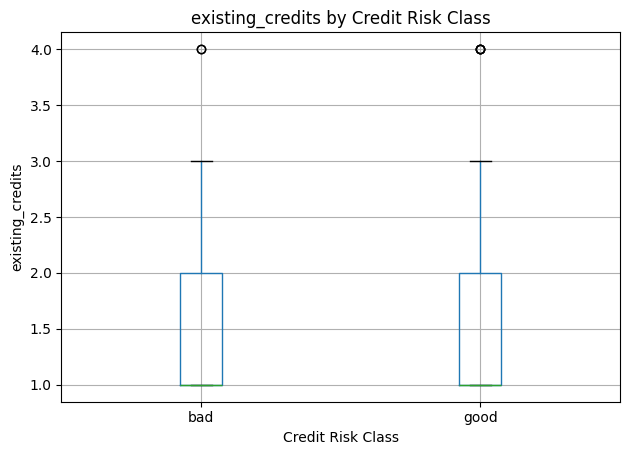

<Figure size 600x400 with 0 Axes>

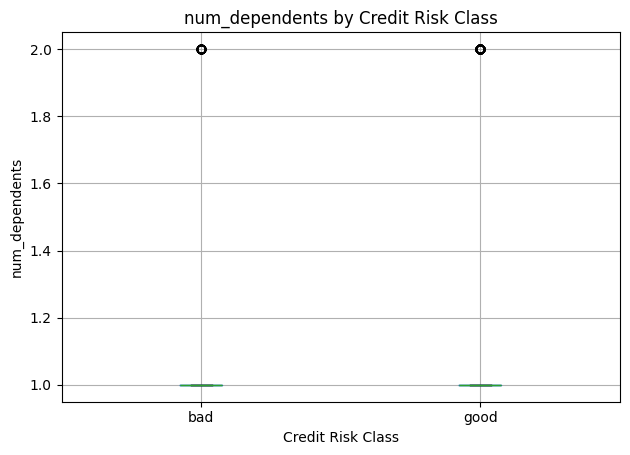

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by="class")
    plt.title(f"{col} by Credit Risk Class")
    plt.suptitle("")
    plt.xlabel("Credit Risk Class")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(figures_path / f"boxplot_{col}_by_class.png")
    plt.show()

The comparison of numerical variables by credit risk class provides an initial indication of which borrower characteristics may be associated with higher credit risk. Variables such as loan duration and credit amount are especially important to inspect, since longer or larger loans may carry different risk profiles. These observations are exploratory and should not be interpreted causally.

## 5. Default Rates Across Categorical Variables

For categorical predictors, it is useful to estimate the proportion of bad credit outcomes within each category. This gives an interpretable first view of which borrower groups may be associated with higher observed credit risk.

In [15]:
df["bad_risk"] = (df["class"] == "bad").astype(int)

In [16]:
categorical_cols = df.select_dtypes(include=["category"]).columns.drop("class")
categorical_cols

Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')

In [17]:
def default_rate_by_category(data, column):
    result = (
        data.groupby(column, observed=True)
        .agg(
            count=("bad_risk", "size"),
            bad_rate=("bad_risk", "mean")
        )
        .sort_values("bad_rate", ascending=False)
    )
    return result

In [18]:
default_rate_by_category(df, "checking_status")

,count,bad_rate
checking_status,,
<0,274,0.492701
0<=X<200,269,0.390335
>=200,63,0.222222
no checking,394,0.116751


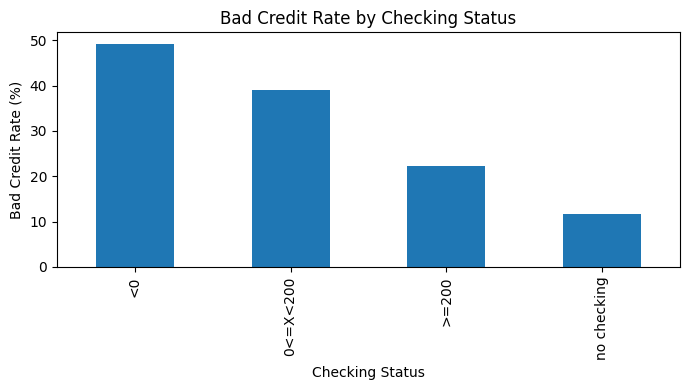

In [19]:
rate_table = default_rate_by_category(df, "checking_status")

plt.figure(figsize=(7, 4))
(rate_table["bad_rate"] * 100).plot(kind="bar")
plt.title("Bad Credit Rate by Checking Status")
plt.xlabel("Checking Status")
plt.ylabel("Bad Credit Rate (%)")
plt.tight_layout()
plt.savefig(figures_path / "bad_rate_by_checking_status.png")
plt.show()

In [20]:
important_categorical_cols = [
    "checking_status",
    "credit_history",
    "savings_status",
    "employment",
    "housing",
    "purpose"
]

for col in important_categorical_cols:
    display(default_rate_by_category(df, col))

,count,bad_rate
checking_status,,
<0,274,0.492701
0<=X<200,269,0.390335
>=200,63,0.222222
no checking,394,0.116751


,count,bad_rate
credit_history,,
no credits/all paid,40,0.625000
all paid,49,0.571429
existing paid,530,0.318868
delayed previously,88,0.318182
critical/other existing credit,293,0.170648


,count,bad_rate
savings_status,,
<100,603,0.359867
100<=X<500,103,0.330097
no known savings,183,0.174863
500<=X<1000,63,0.174603
>=1000,48,0.125000


,count,bad_rate
employment,,
<1,172,0.406977
unemployed,62,0.370968
1<=X<4,339,0.306785
>=7,253,0.252964
4<=X<7,174,0.224138


,count,bad_rate
housing,,
for free,108,0.407407
rent,179,0.391061
own,713,0.260870


,count,bad_rate
purpose,,
education,50,0.440000
other,12,0.416667
new car,234,0.380342
repairs,22,0.363636
business,97,0.350515
domestic appliance,12,0.333333
furniture/equipment,181,0.320442
radio/tv,280,0.221429
used car,103,0.165049


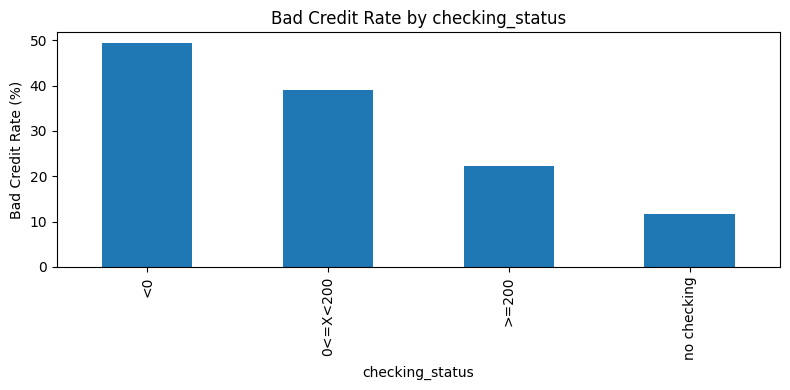

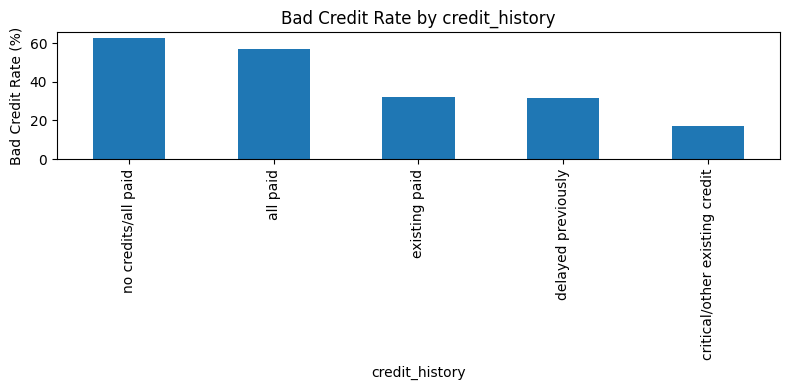

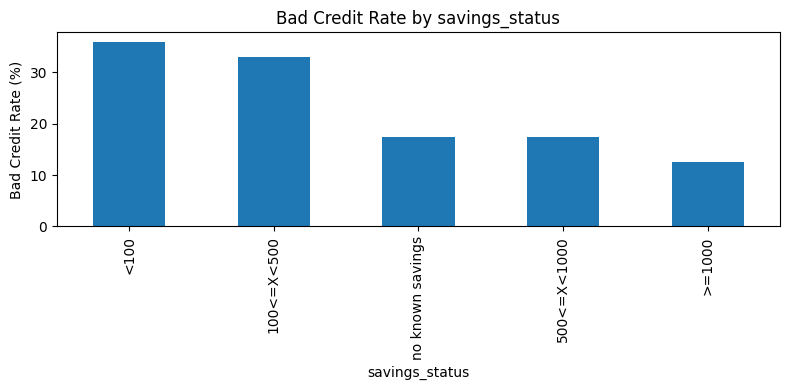

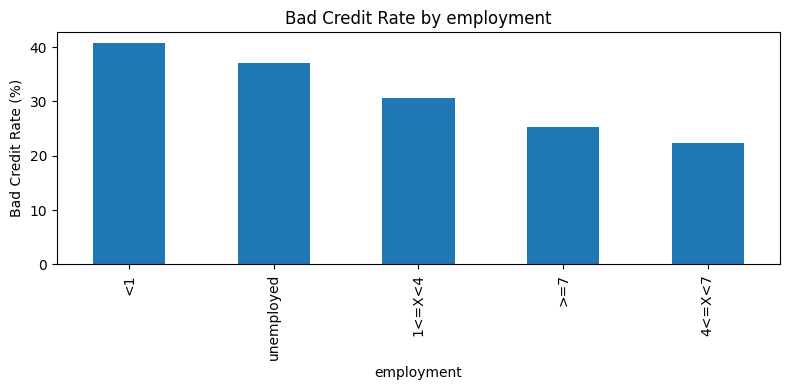

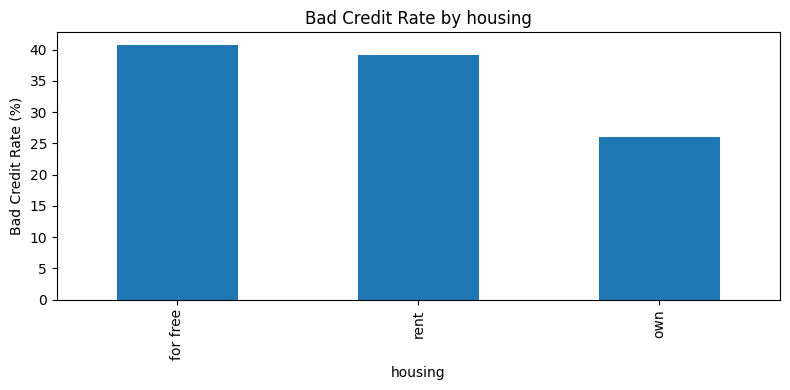

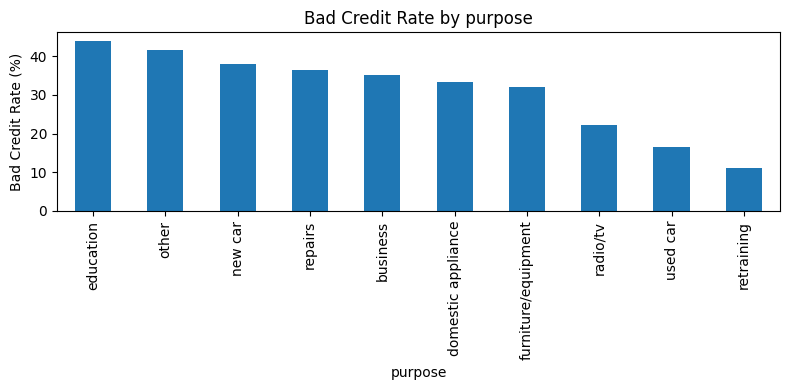

In [21]:
for col in important_categorical_cols:
    rate_table = default_rate_by_category(df, col)

    plt.figure(figsize=(8, 4))
    (rate_table["bad_rate"] * 100).plot(kind="bar")
    plt.title(f"Bad Credit Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Bad Credit Rate (%)")
    plt.tight_layout()
    plt.savefig(figures_path / f"bad_rate_by_{col}.png")
    plt.show()

### Categorical Default Rate Analysis

The observed bad credit rate varies substantially across categorical borrower characteristics.

The strongest difference appears in `checking_status`. Borrowers with checking status `<0` have an observed bad credit rate of approximately 49.3%, while borrowers with `no checking` have a much lower bad credit rate of approximately 11.7%. This suggests that checking account status is likely to be a highly informative predictor in the credit risk model.

Credit history is also strongly associated with observed credit risk. Borrowers with `no credits/all paid` or `all paid` have bad credit rates above 55%, while borrowers with `critical/other existing credit` have a much lower bad credit rate of approximately 17.1%.

Savings status shows a clear gradient. Borrowers with savings below 100 have a bad credit rate of approximately 36.0%, while borrowers with savings above 1000 have a bad credit rate of approximately 12.5%.

Employment status also appears relevant. Borrowers employed for less than one year have a bad credit rate of approximately 40.7%, compared with approximately 22.4% for borrowers employed between four and seven years.

Housing status shows that borrowers living for free or renting have higher observed bad credit rates than borrowers who own their housing.

These descriptive patterns suggest that checking status, credit history, savings status, employment, and housing should be included as predictors in the baseline model. However, these are marginal comparisons and do not account for interactions or confounding between variables.

## 6. Summary of Exploratory Findings

The exploratory analysis suggests several important patterns:

- The target variable is moderately imbalanced, with 70% good credit outcomes and 30% bad credit outcomes.
- Bad credit risk borrowers tend to have longer loan durations and higher average credit amounts.
- Checking account status shows one of the strongest differences in observed bad credit rates.
- Credit history, savings status, employment status, and housing status also show meaningful differences in bad credit rates.
- Some categorical variables contain small groups, so category-level bad rates should be interpreted carefully.
- The analysis is descriptive and does not establish causal relationships.

These findings motivate the construction of a baseline logistic regression model using both numerical and categorical predictors. Since the dataset contains many categorical variables, appropriate encoding is required before fitting the model.

## 7. Baseline Logistic Regression Model

The exploratory analysis suggests that both numerical and categorical variables are relevant for credit risk classification. As a first interpretable baseline model, logistic regression is used.

The target variable is transformed into a binary variable, where `1` represents bad credit risk and `0` represents good credit risk. Numerical variables are standardized using `StandardScaler`, while categorical variables are one-hot encoded. Standardization is used because logistic regression is sensitive to feature scaling, especially when variables such as `credit_amount`, `duration`, and `age` are measured on different scales.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)


In [23]:
X = df.drop(columns=["class", "bad_risk"])
y = df["bad_risk"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["category"]).columns

numeric_features, categorical_features

(Index(['duration', 'credit_amount', 'installment_commitment',
        'residence_since', 'age', 'existing_credits', 'num_dependents'],
       dtype='object'),
 Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
        'employment', 'personal_status', 'other_parties', 'property_magnitude',
        'other_payment_plans', 'housing', 'job', 'own_telephone',
        'foreign_worker'],
       dtype='object'))

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numeric_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [26]:
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [28]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

accuracy, roc_auc

(0.78, 0.8040476190476191)

In [29]:
print(classification_report(y_test, y_pred, target_names=["good", "bad"]))

              precision    recall  f1-score   support

        good       0.82      0.89      0.85       140
         bad       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



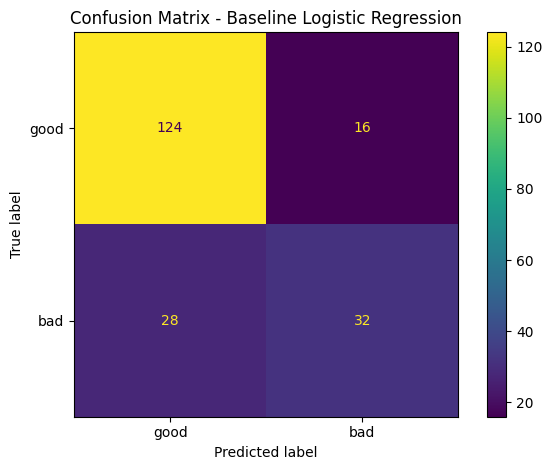

In [30]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["good", "bad"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.tight_layout()
plt.savefig(figures_path / "confusion_matrix_baseline_logistic_regression.png")
plt.show()

### Baseline Model Interpretation

The baseline logistic regression model achieves an accuracy of 0.78 and a ROC-AUC of approximately 0.804 on the test set. At first sight, this appears to be a reasonably strong result for a simple interpretable model. However, because the target variable is imbalanced, with 70% good credit cases and 30% bad credit cases, accuracy alone is not sufficient for evaluating the model.

The classification report gives a more informative picture. The model performs well on the good credit class, with precision 0.82, recall 0.89, and F1-score 0.85. This means that the model is effective at identifying borrowers classified as good credit risks. In the test set, it correctly classifies 124 out of 140 good credit cases.

The performance on the bad credit class is weaker. For bad credit risk borrowers, the model achieves precision 0.67, recall 0.53, and F1-score 0.59. The recall of 0.53 means that the model identifies only 32 out of 60 bad credit cases. Equivalently, it misses 28 bad credit borrowers, classifying them as good credit risks.

This is the main weakness of the baseline model. In credit risk analysis, false negatives are often especially costly. A false negative corresponds to a borrower who is predicted to be a good credit risk but is actually classified as a bad credit risk. In a lending context, this type of error may lead to approving loans that later default or underperform.

The confusion matrix makes this tradeoff concrete. The baseline model produces 124 true negatives, 16 false positives, 28 false negatives, and 32 true positives. The relatively small number of false positives indicates that the model is conservative in assigning the bad-risk label. However, this conservatism comes at the cost of missing many bad credit cases.

The ROC-AUC of approximately 0.804 indicates that the model has useful discriminatory ability: it can rank good and bad credit cases reasonably well across possible classification thresholds. However, the default threshold of 0.5 does not necessarily produce the best business decision rule. This motivates the later threshold tuning analysis.

Overall, the baseline logistic regression model is a useful first benchmark. It is interpretable, stable, and has reasonable overall performance. Its main limitation is insufficient recall for the bad credit risk class.

## 8. Logistic Regression with Class Weighting

The baseline logistic regression model performs reasonably well overall, but it has limited recall for the bad credit risk class. Since the target variable is imbalanced, a second logistic regression model is fitted using class weighting.

The purpose of class weighting is to assign greater importance to the minority class during training. In this dataset, the bad credit risk class represents 30% of the observations, so class weighting may improve the model's ability to detect bad credit risk borrowers.

In [31]:
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

balanced_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_balanced = balanced_model.predict(X_test)
y_proba_balanced = balanced_model.predict_proba(X_test)[:, 1]

In [33]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_proba_balanced)

accuracy_balanced, roc_auc_balanced

(0.75, 0.8058333333333333)

In [34]:
print(classification_report(y_test, y_pred_balanced, target_names=["good", "bad"]))

              precision    recall  f1-score   support

        good       0.89      0.73      0.80       140
         bad       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200



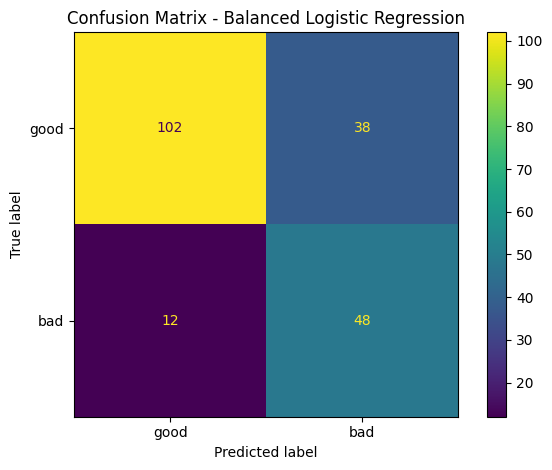

In [35]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["good", "bad"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.tight_layout()
plt.savefig(figures_path / "confusion_matrix_balanced_logistic_regression.png")
plt.show()

In [36]:
model_comparison = pd.DataFrame({
    "model": ["Baseline Logistic Regression", "Balanced Logistic Regression"],
    "accuracy": [accuracy, accuracy_balanced],
    "roc_auc": [roc_auc, roc_auc_balanced]
})

model_comparison

,model,accuracy,roc_auc
0,Baseline Logistic Regression,0.78,0.804048
1,Balanced Logistic Regression,0.75,0.805833


### Comparison of Baseline and Balanced Logistic Regression

The class-weighted logistic regression model changes the nature of the classification tradeoff. Its accuracy decreases from 0.78 to 0.75, while ROC-AUC remains almost unchanged, increasing slightly from approximately 0.804 to 0.806. This is important: the similar ROC-AUC values suggest that the two models have comparable ranking ability, but they operate at different classification tradeoffs.

The main improvement is in the bad credit class. The baseline model has bad-class recall 0.53, while the balanced model improves bad-class recall to 0.80. In practical terms, the balanced model correctly identifies 48 out of 60 bad credit cases, compared with only 32 out of 60 for the baseline model.

This improvement comes with a cost. The balanced model produces more false positives. In the confusion matrix, the number of good credit borrowers incorrectly classified as bad increases from 16 in the baseline model to 38 in the balanced model. This means that the balanced model rejects or flags more borrowers who are actually good credit risks.

The two models therefore represent different business strategies. The baseline model is more selective when predicting bad credit risk. It makes fewer false positive errors, but it misses many bad credit borrowers. The balanced model is more aggressive in detecting bad credit risk. It captures many more risky borrowers, but it also flags more good borrowers as risky.

In a credit risk setting, neither model is automatically “better” in an absolute sense. The preferred model depends on the relative cost of false negatives and false positives. If false negatives are very costly because approving risky borrowers leads to loan losses, then the balanced model is preferable. If false positives are very costly because rejecting good borrowers reduces revenue or damages customer relationships, then the baseline model may be more attractive.

From a risk-management perspective, the balanced model is more aligned with a conservative lending policy. It sacrifices some overall accuracy in exchange for substantially better detection of bad credit risk borrowers. This is often a reasonable tradeoff when the minority class represents the main source of financial risk.


## 9. Cross-Validation

The previous model comparison was based on a single train-test split. To obtain a more stable estimate of model performance, 5-fold stratified cross-validation is used.

Stratification preserves the proportion of good and bad credit risk cases in each fold, which is important because the target variable is imbalanced.

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "precision_bad": "precision",
    "recall_bad": "recall",
    "f1_bad": "f1"
}

In [38]:
cv_results_baseline = cross_validate(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [39]:
cv_results_balanced = cross_validate(
    balanced_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [40]:
metrics = ["accuracy", "roc_auc", "precision_bad", "recall_bad", "f1_bad"]

cv_summary = pd.DataFrame({
    "metric": metrics,
    "baseline_mean": [cv_results_baseline[f"test_{m}"].mean() for m in metrics],
    "baseline_std": [cv_results_baseline[f"test_{m}"].std() for m in metrics],
    "balanced_mean": [cv_results_balanced[f"test_{m}"].mean() for m in metrics],
    "balanced_std": [cv_results_balanced[f"test_{m}"].std() for m in metrics],
})

cv_summary

,metric,baseline_mean,baseline_std,balanced_mean,balanced_std
0,accuracy,0.748000,0.012083,0.719000,0.027459
1,roc_auc,0.786167,0.019771,0.785524,0.019151
2,precision_bad,0.605254,0.028598,0.523911,0.034119
3,recall_bad,0.463333,0.016330,0.720000,0.041366
4,f1_bad,0.524621,0.018479,0.606120,0.034242


### Cross-Validation Interpretation

The 5-fold stratified cross-validation results support the pattern observed in the test-set evaluation. The baseline model has higher average accuracy, while the class-weighted model provides stronger detection of the bad credit risk class.

The most important cross-validation result is the difference in bad-class recall. The baseline model identifies less than half of the bad credit risk cases on average, while the balanced model identifies a substantially larger proportion. This indicates that the improvement in bad-risk detection is not simply an artifact of one particular train-test split.

The balanced model also improves the bad-class F1-score, suggesting a better compromise between precision and recall for the minority class. Its lower precision means that it generates more false positives, but this is the expected cost of increasing recall.

The ROC-AUC values are similar across the two models, which suggests that class weighting mainly changes the classification tradeoff rather than the model's overall ranking ability.

## 10. Threshold Tuning

The default classification threshold for logistic regression is 0.5. However, in credit risk analysis, this threshold may not be optimal.

Lowering the threshold classifies more borrowers as bad credit risks, which can increase recall for the bad class but may also increase false positives. Threshold tuning allows us to study this tradeoff explicitly.

In [41]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred_threshold,
        average="binary",
        zero_division=0
    )
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    threshold_rows.append({
        "threshold": threshold,
        "precision_bad": precision,
        "recall_bad": recall,
        "f1_bad": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,threshold,precision_bad,recall_bad,f1_bad,true_negatives,false_positives,false_negatives,true_positives
0,0.10,0.364865,0.900000,0.519231,46,94,6,54
1,0.15,0.410853,0.883333,0.560847,64,76,7,53
2,0.20,0.458716,0.833333,0.591716,81,59,10,50
3,0.25,0.505155,0.816667,0.624204,92,48,11,49
4,0.30,0.563218,0.816667,0.666667,102,38,11,49
5,0.35,0.597403,0.766667,0.671533,109,31,14,46
6,0.40,0.632353,0.716667,0.671875,115,25,17,43
7,0.45,0.620690,0.600000,0.610169,118,22,24,36
8,0.50,0.666667,0.533333,0.592593,124,16,28,32
9,0.55,0.707317,0.483333,0.574257,128,12,31,29


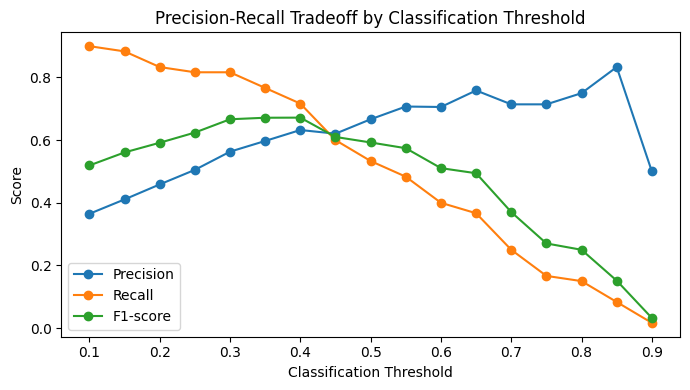

In [42]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_results["threshold"], threshold_results["precision_bad"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall_bad"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1_bad"], marker="o", label="F1-score")
plt.title("Precision-Recall Tradeoff by Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(figures_path / "threshold_tuning_precision_recall.png")
plt.show()

In [43]:
best_f1_threshold = threshold_results.loc[
    threshold_results["f1_bad"].idxmax()
]

best_f1_threshold

threshold            0.400000
precision_bad        0.632353
recall_bad           0.716667
f1_bad               0.671875
true_negatives     115.000000
false_positives     25.000000
false_negatives     17.000000
true_positives      43.000000
Name: 6, dtype: float64

In [44]:
high_recall_thresholds = threshold_results[
    threshold_results["recall_bad"] >= 0.75
].sort_values("precision_bad", ascending=False)

high_recall_thresholds.head()

,threshold,precision_bad,recall_bad,f1_bad,true_negatives,false_positives,false_negatives,true_positives
5,0.35,0.597403,0.766667,0.671533,109,31,14,46
4,0.30,0.563218,0.816667,0.666667,102,38,11,49
3,0.25,0.505155,0.816667,0.624204,92,48,11,49
2,0.20,0.458716,0.833333,0.591716,81,59,10,50
1,0.15,0.410853,0.883333,0.560847,64,76,7,53


### Threshold Tuning Interpretation

The threshold tuning analysis studies how the classification decision changes when the probability cutoff is varied. The default logistic regression threshold is 0.5, meaning that a borrower is classified as bad credit risk if the predicted probability of bad credit is at least 50%. However, there is no reason this threshold must be optimal in a credit risk context.

At the default threshold of 0.50, the baseline model has bad-class precision 0.667 and bad-class recall 0.533. This means that its bad-risk predictions are relatively precise, but it misses many bad credit cases. Specifically, at this threshold, the model produces 28 false negatives.

Lowering the threshold makes the model more willing to classify borrowers as bad credit risks. This generally increases recall but decreases precision. For example, at threshold 0.40, the model achieves bad-class precision 0.632, recall 0.717, and F1-score 0.672. This is the threshold with the best F1-score in the tested range. It reduces false negatives from 28 to 17, while increasing false positives from 16 to 25.

A threshold of 0.35 gives even higher bad-class recall, approximately 0.767, while keeping precision at approximately 0.597. At this threshold, the model produces 14 false negatives and 31 false positives. This may be attractive if the institution strongly prioritizes detecting risky borrowers and is willing to accept more false positive cases.

More aggressive thresholds, such as 0.20 or 0.15, produce very high recall but much lower precision. These thresholds identify most bad credit risk borrowers, but they also classify many good borrowers as bad risks. Such thresholds may be too conservative in practice unless the cost of approving a risky borrower is extremely high.

This analysis shows that model evaluation should not stop at fitting a classifier. In credit risk, the predicted probability is often more useful than the default binary prediction. The probability score allows the lender to choose a threshold that reflects its risk appetite, expected losses, approval policy, and regulatory constraints.

The threshold choice is therefore a business decision, not only a statistical decision. A model with good ranking ability can support different lending strategies depending on where the classification threshold is placed.

This threshold tuning analysis is exploratory because it uses the test set for illustration. In a production workflow, the threshold should be selected using a validation set or cross-validation procedure, and the final chosen threshold should then be evaluated on a separate holdout test set.

## 11. Business Decision Interpretation

The results should be interpreted as a decision-support problem, not only as a classification exercise. In credit risk, the two error types have different business meanings.

A false negative means that a borrower is predicted as good credit risk but belongs to the bad credit class. This may expose the lender to credit losses. A false positive means that a borrower is predicted as bad credit risk but belongs to the good credit class. This may reduce revenue by rejecting or flagging a potentially profitable customer.

The baseline model is more permissive: it produces fewer false positives but misses more bad credit cases. The balanced model is more conservative: it detects more bad credit cases but flags more good borrowers as risky.

Threshold tuning adds another layer of control. Instead of accepting the default 0.5 cutoff, a lender could choose a threshold that reflects its risk appetite. A lower threshold increases bad-risk detection, while a higher threshold reduces false positives.

Without explicit financial costs for false positives and false negatives, there is no universally optimal model. The appropriate choice depends on the lending policy: a growth-oriented lender may prefer fewer false positives, while a risk-averse lender may prefer stronger bad-risk detection.

## 12. Model Interpretability

Logistic regression is useful as a baseline model because its coefficients can be inspected. Positive coefficients increase the predicted log-odds of bad credit risk, while negative coefficients decrease them.

Because the model uses standardized numerical variables and one-hot encoded categorical variables, the coefficients should be interpreted as directional indicators rather than causal effects.

In [45]:
feature_names = balanced_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = balanced_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,odds_ratio
11,purpose_education,0.958526,2.607851
38,property_magnitude_no known property,0.635350,1.887683
1,checking_status_<0,0.620797,1.860409
8,credit_history_no credits/all paid,0.589948,1.803894
21,savings_status_<100,0.584578,1.794233
16,purpose_repairs,0.573417,1.774319
53,foreign_worker_yes,0.568303,1.765269
13,purpose_new car,0.488497,1.629864
45,housing_rent,0.460398,1.584705
40,other_payment_plans_bank,0.428027,1.534227


In [46]:
coef_df.tail(15)

,feature,coefficient,odds_ratio
48,job_unemp/unskilled non res,-0.326660,0.721329
17,purpose_retraining,-0.341473,0.710722
23,savings_status_no known savings,-0.349568,0.704993
39,property_magnitude_real estate,-0.392417,0.675423
41,other_payment_plans_none,-0.446325,0.639975
34,other_parties_guarantor,-0.452236,0.636204
43,housing_for free,-0.505850,0.602993
32,personal_status_male single,-0.535998,0.585085
14,purpose_other,-0.589430,0.554643
25,employment_4<=X<7,-0.595362,0.551363


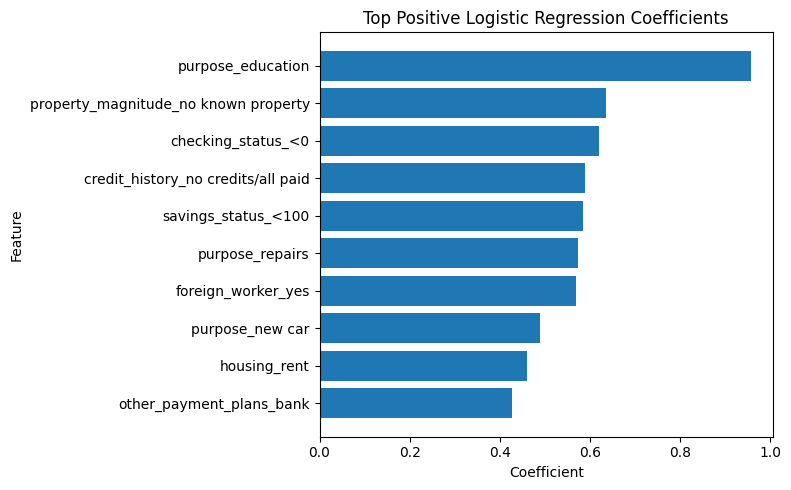

In [47]:
top_positive = coef_df.head(10).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_positive["feature"], top_positive["coefficient"])
plt.title("Top Positive Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_path / "top_positive_coefficients.png")
plt.show()

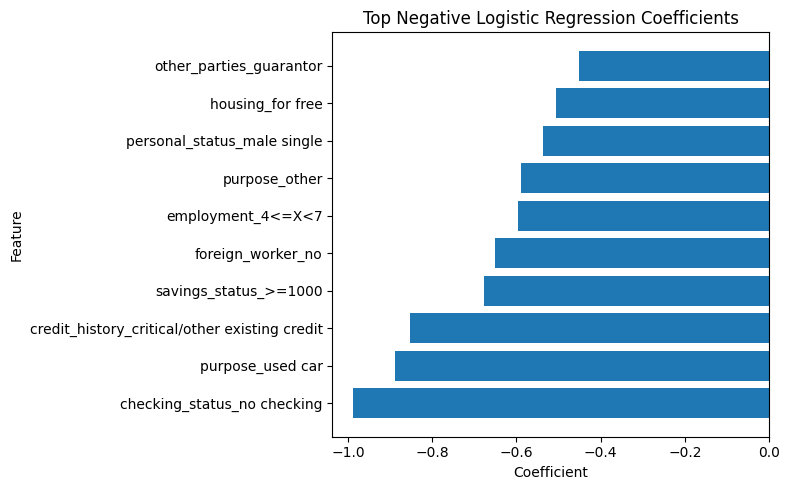

In [48]:
top_negative = coef_df.tail(10).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_negative["feature"], top_negative["coefficient"])
plt.title("Top Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_path / "top_negative_coefficients.png")
plt.show()

### Coefficient Interpretation

One advantage of logistic regression is that its coefficients can be inspected directly. In this model, positive coefficients increase the predicted log-odds of bad credit risk, while negative coefficients decrease the predicted log-odds of bad credit risk.

The largest positive coefficients are associated with variables such as `purpose_education`, `property_magnitude_no known property`, `checking_status_<0`, `credit_history_no credits/all paid`, `savings_status_<100`, and `purpose_repairs`. These features are associated with higher predicted probability of bad credit risk, holding the other encoded variables fixed in the fitted model.

The coefficient for `checking_status_<0` is especially consistent with the earlier exploratory analysis. Borrowers with negative checking account status had one of the highest observed bad credit rates in the categorical analysis. The positive coefficient in the logistic regression model confirms that this variable remains an important risk indicator even after accounting for other borrower characteristics.

The positive coefficient for `savings_status_<100` is also consistent with the descriptive analysis. Lower savings status is associated with higher observed bad credit rates, and the model uses this information when assigning higher predicted risk.

The positive coefficient for `credit_amount` indicates that, after standardization and conditional on the other variables in the model, larger credit amounts are associated with higher predicted probability of bad credit risk. This agrees with the numerical EDA, where bad credit risk borrowers had higher average credit amounts.

The largest negative coefficients include variables such as `credit_history_critical/other existing credit`, `savings_status_>=1000`, `foreign_worker_no`, `employment_4<=X<7`, `personal_status_male single`, and `other_parties_guarantor`. These features are associated with lower predicted probability of bad credit risk in the fitted model.

The negative coefficient for `savings_status_>=1000` is intuitive: borrowers with higher savings are predicted to have lower credit risk. The negative coefficient for `other_parties_guarantor` also makes sense from a credit-risk perspective, since the presence of a guarantor may reduce the effective risk faced by the lender.

The coefficient interpretation should be treated carefully. These coefficients are not causal effects. They do not prove that changing a borrower characteristic would change credit risk. They describe associations learned by the model from this dataset.

The coefficient interpretation should be treated carefully. These coefficients are not causal effects; they describe associations learned by the fitted model. In this notebook, one-hot encoding is used without explicitly dropping a reference category, so the coefficients should be viewed as directional indicators of model behavior rather than clean comparisons against a single omitted reference group. For formal econometric interpretation, one category per categorical variable should be dropped and coefficients should be interpreted relative to chosen reference categories.

Nevertheless, the coefficient analysis is useful because it connects the statistical model back to the exploratory analysis. The same variables that showed strong descriptive differences, such as checking status, savings status, credit history, and credit amount, also appear among the important model drivers. This gives the model a degree of interpretability and makes the results easier to communicate in a risk-analysis context.

## 13. Project Summary

This project analyzes the German Credit dataset as a binary credit risk classification problem. The workflow includes data inspection, exploratory analysis, baseline modeling, class imbalance handling, cross-validation, threshold tuning, and coefficient-based interpretation.

The exploratory analysis shows that the target variable is moderately imbalanced, with 70% good credit outcomes and 30% bad credit outcomes. Bad credit risk borrowers tend to have longer loan durations and higher average credit amounts. Several categorical variables, including checking status, credit history, savings status, employment status, and housing status, show substantial variation in observed bad credit rates.

Two logistic regression models are compared. The baseline model achieves stronger overall accuracy, while the class-weighted model substantially improves recall for the bad credit risk class. Cross-validation supports this tradeoff and suggests that the balanced model is more appropriate when the main objective is identifying risky borrowers.

Threshold tuning shows that the default 0.5 classification threshold is not necessarily optimal. Lower thresholds can increase bad-risk recall, but at the cost of more false positives. This reinforces the idea that credit risk modeling requires both statistical evaluation and business judgment.

The coefficient analysis provides an interpretable view of the main model drivers. Variables related to checking status, savings status, credit history, credit amount, property status, and loan purpose are among the strongest contributors to the model's predictions.

Further work could include probability calibration, cost-sensitive evaluation, tree-based models, feature importance comparison, and a more formal validation framework.

## Executive Conclusion

This project demonstrates a complete first credit risk modeling workflow using Python and scikit-learn.

The main result is that the baseline logistic regression model performs better in terms of overall accuracy, while the class-weighted model is better at detecting bad credit risk borrowers. This illustrates a central credit risk tradeoff: a model that maximizes accuracy may not be the best model for risk management.

The project also shows that classification thresholds matter. By changing the probability cutoff, a lender can move between a more permissive and a more conservative approval policy.

Overall, the notebook demonstrates practical ability in exploratory data analysis, statistical modeling, class imbalance handling, model evaluation, threshold analysis, and interpretable machine learning. It is suitable as a first portfolio project for data analyst, statistical analyst, credit risk analyst, or junior data scientist roles.
